## Importing Libraries and Reading Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import missingno
from sklearn.model_selection import train_test_split


df = pd.read_csv("hf://datasets/dazzle-nu/CIS435-CreditCardFraudDetection/fraudTrain.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,Unnamed: 23,6006
0,0,1/1/19 0:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,3495,"Psychologist, counselling",3/9/88,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,NaN,NaN
1,1,1/1/19 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,149,Special educational needs teacher,6/21/78,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN,NaN
2,2,1/1/19 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,4154,Nature conservation officer,1/19/62,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,NaN,NaN
3,3,1/1/19 0:01,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,1939,Patent attorney,1/12/67,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN,NaN
4,4,1/1/19 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,99,Dance movement psychotherapist,3/28/86,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,NaN,NaN


## Data Cleaning

<Axes: >

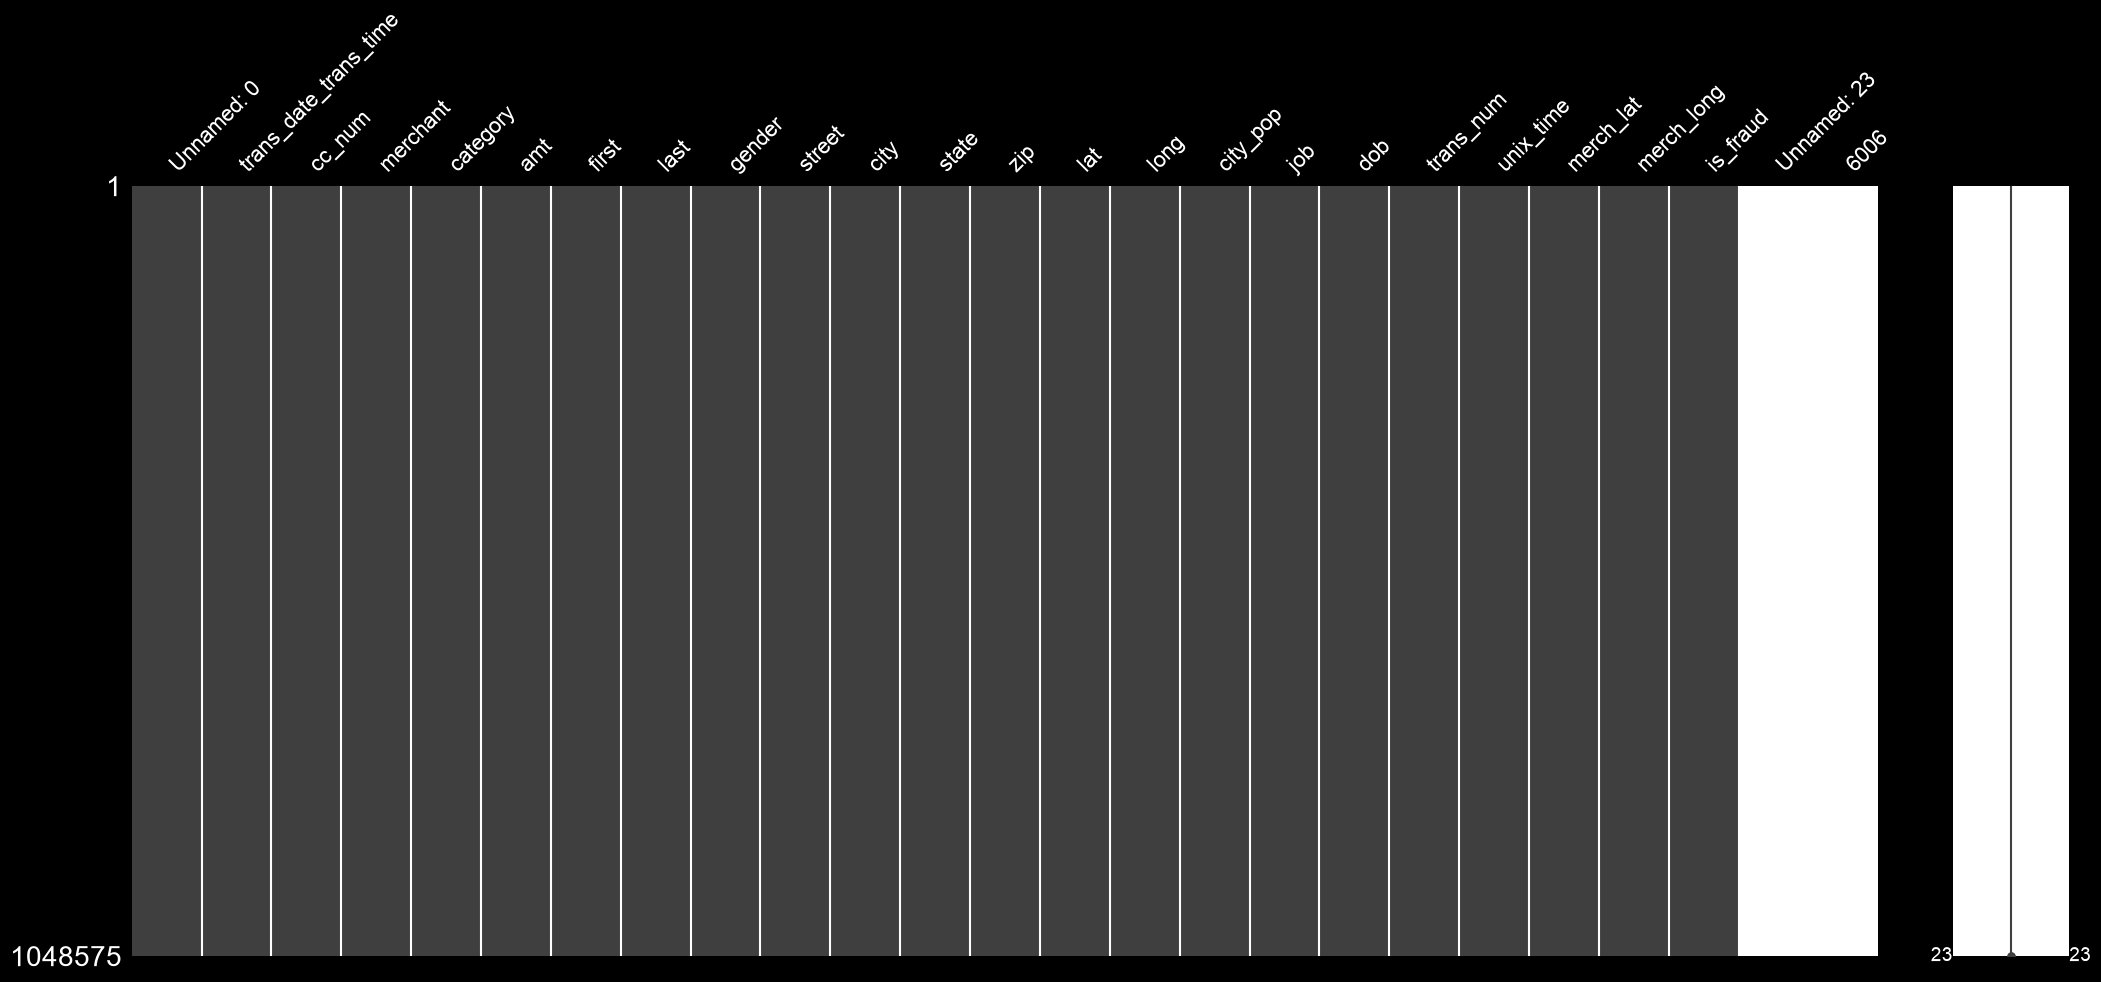

In [2]:
missingno.matrix(df)

In [3]:
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 23', '6006'])

In [4]:
print(len(df[df.duplicated()]))

0


In [5]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,1/1/19 0:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",3/9/88,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1/1/19 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,6/21/78,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,1/1/19 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1/19/62,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,1/1/19 0:01,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1/12/67,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,1/1/19 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,3/28/86,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Data Manipulation

In [6]:
# Split the transaction timestamp into date and time columns.
if "trans_date_trans_time" in df.columns:
    transaction_timestamp = pd.to_datetime(
        df["trans_date_trans_time"],
        format="%m/%d/%y %H:%M"
    )

    df["trans_date"] = transaction_timestamp.dt.date
    df["trans_time"] = transaction_timestamp.dt.time
    df = df.drop(columns=["trans_date_trans_time"])

In [7]:
df["merchant"] = df["merchant"].str.replace("fraud_", "", regex=False)

In [8]:
df.head()

,cc_num,merchant,category,amt,first,last,gender,street,city,state,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_date,trans_time
0,2.703190e+15,"Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,...,3495,"Psychologist, counselling",3/9/88,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019-01-01,00:00:00
1,6.304230e+11,"Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,...,149,Special educational needs teacher,6/21/78,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019-01-01,00:00:00
2,3.885950e+13,Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,...,4154,Nature conservation officer,1/19/62,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019-01-01,00:00:00
3,3.534090e+15,"Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,...,1939,Patent attorney,1/12/67,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019-01-01,00:01:00
4,3.755340e+14,Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,...,99,Dance movement psychotherapist,3/28/86,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019-01-01,00:03:00


## Fixing Class Imbalance Using Random Undersampling

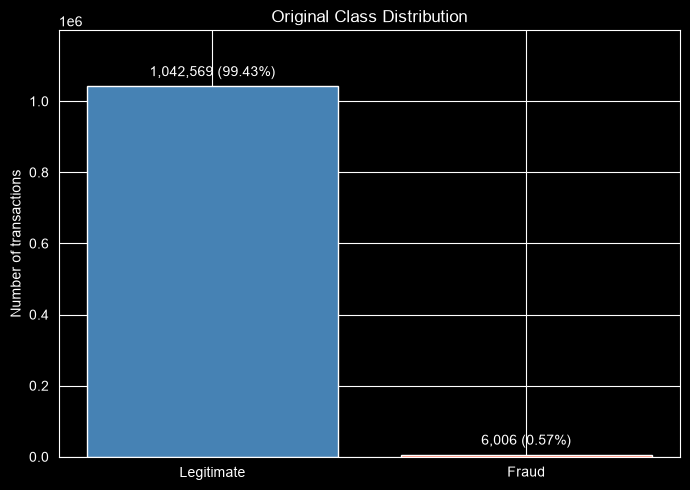

In [9]:
def plot_class_balance(data, title):
    counts = data["is_fraud"].value_counts().reindex([0, 1], fill_value=0)
    percentages = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(
        ["Legitimate", "Fraud"],
        counts.values,
        color=["steelblue", "tomato"]
    )

    ax.bar_label(
        bars,
        labels=[
            f"{count:,} ({pct:.2f}%)"
            for count, pct in zip(counts, percentages)
        ],
        padding=5
    )
    ax.set(title=title, ylabel="Number of transactions")
    ax.set_ylim(0, counts.max() * 1.15)
    plt.tight_layout()
    plt.show()

plot_class_balance(df, "Original Class Distribution")

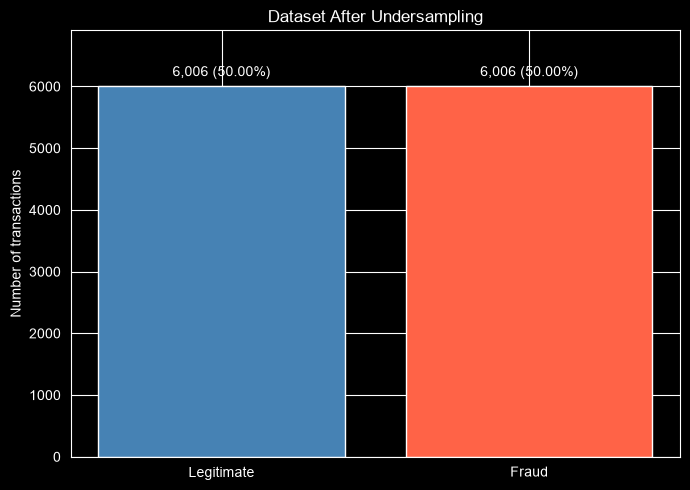

In [10]:
class_counts = df["is_fraud"].value_counts()
samples_per_class = class_counts.min()
df_balanced = pd.concat([
    group.sample(n=samples_per_class, random_state=42)
    for _, group in df.groupby("is_fraud")
]).sample(frac=1, random_state=42).reset_index(drop=True)

plot_class_balance(df_balanced, "Dataset After Undersampling")

## Filtering outliers using IQR

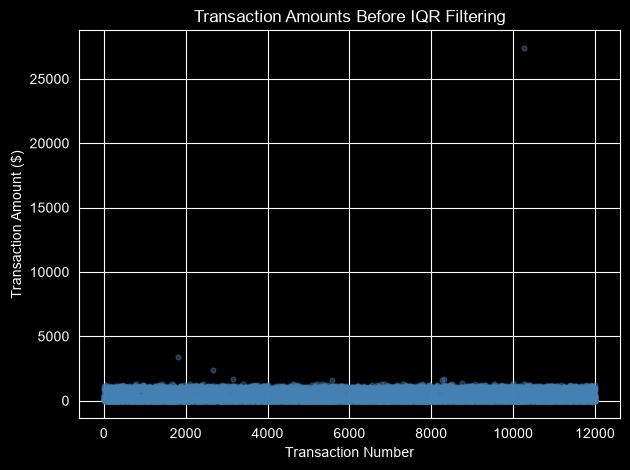

In [11]:
plt.scatter(
    range(len(df_balanced)),
    df_balanced["amt"],
    alpha=0.4,
    s=12,
    color="steelblue"
)

plt.title("Transaction Amounts Before IQR Filtering")
plt.xlabel("Transaction Number")
plt.ylabel("Transaction Amount ($)")
plt.tight_layout()
plt.show()

In [12]:
# Calculating Q1 and Q2
Q1 = df_balanced['amt'].quantile(0.25)
Q3 = df_balanced['amt'].quantile(0.75)
IQR = Q3 - Q1

# Defining upper and lower bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Removing outliers
df_final = df_balanced[(df_balanced['amt'] >= lower_bound) & (df_balanced['amt'] <= upper_bound)]

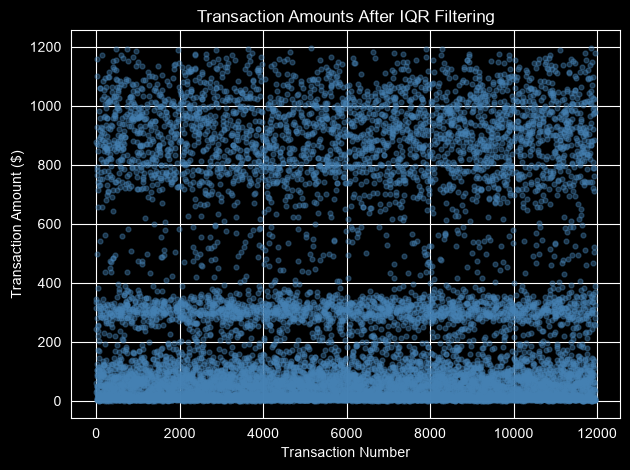

In [13]:
plt.scatter(
    range(len(df_final)),
    df_final["amt"],
    alpha=0.4,
    s=12,
    color="steelblue"
)

plt.title("Transaction Amounts After IQR Filtering")
plt.xlabel("Transaction Number")
plt.ylabel("Transaction Amount ($)")
plt.tight_layout()
plt.show()

## Shuffling Dataset

In [14]:
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

## Splitting Dataset into Training and Testing

In [15]:
train_df, test_df = train_test_split(
    df_final,
    test_size=0.2,
    stratify=df_final["is_fraud"],
    random_state=42
)

# Training and testing variables
X_train = train_df.drop(columns="is_fraud")

X_test = test_df.drop(columns="is_fraud")
y_test = test_df["is_fraud"]